# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.15.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 [=========================] - 5s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

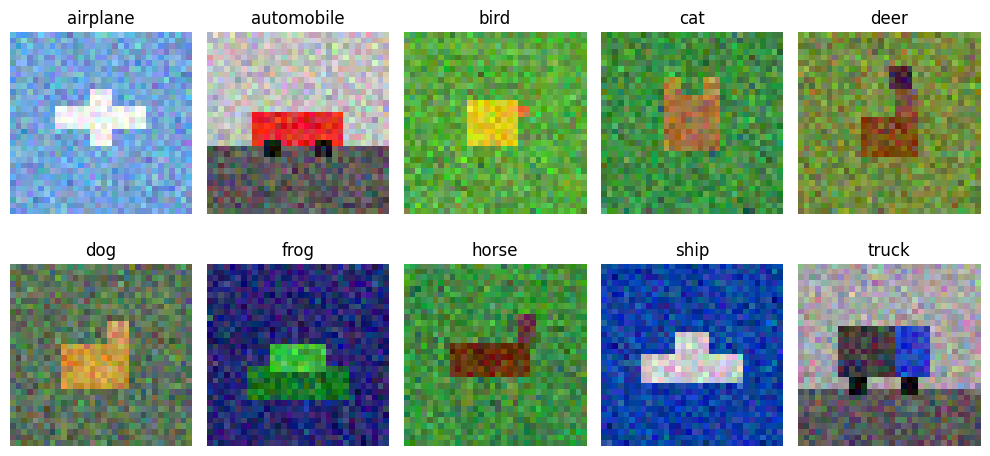

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 [==============================] - 3s 4ms/step - loss: 1.9728 - accuracy: 0.2888 - val_loss: 1.8730 - val_accuracy: 0.3235
Epoch 2/10
704/704 [==============================] - 3s 4ms/step - loss: 1.8726 - accuracy: 0.3201 - val_loss: 1.7697 - val_accuracy: 0.3515
Epoch 3/10
704/704 [==============================] - 3s 4ms/step - loss: 1.7542 - accuracy: 0.3526 - val_loss: 1.7074 - val_accuracy: 0.3799
Epoch 4/10
704/704 [==============================] - 3s 4ms/step - loss: 1.6706 - accuracy: 0.3664 - val_loss: 1.6238 - val_accuracy: 0.4022
Epoch 5/10
704/704 [==============================] - 3s 4ms/step - loss: 1.6405 - accuracy: 0.3885 - val_loss: 1.5904 - val_accuracy: 0.4012
Epoch 6/10
704/704 [==============================] - 3s 4ms/step - loss: 1.5769 - accuracy: 0.4050 - val_loss: 1.5824 - val_accuracy: 0.4092
Epoch 7/10
704/704 [==============================] - 3s 4ms/step - loss: 1.5652 - accuracy: 0.4066 - val_loss: 1.5577 - val_accuracy: 0.4276
Epoch 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 [==============================] - 1s 2ms/step - loss: 1.5824 - accuracy: 0.4092
ANN Test Accuracy: 0.409246


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 [==============================] - 12s 17ms/step - loss: 1.7236 - accuracy: 0.3776 - val_loss: 1.5039 - val_accuracy: 0.4644
Epoch 2/10
704/704 [==============================] - 12s 17ms/step - loss: 1.5252 - accuracy: 0.4587 - val_loss: 1.3269 - val_accuracy: 0.5232
Epoch 3/10
704/704 [==============================] - 12s 17ms/step - loss: 1.3458 - accuracy: 0.5161 - val_loss: 1.1986 - val_accuracy: 0.5676
Epoch 4/10
704/704 [==============================] - 12s 17ms/step - loss: 1.2344 - accuracy: 0.5640 - val_loss: 1.1216 - val_accuracy: 0.6006
Epoch 5/10
704/704 [==============================] - 12s 17ms/step - loss: 1.0933 - accuracy: 0.6116 - val_loss: 1.0581 - val_accuracy: 0.6188
Epoch 6/10
704/704 [==============================] - 12s 17ms/step - loss: 1.0504 - accuracy: 0.6436 - val_loss: 1.0062 - val_accuracy: 0.6421
Epoch 7/10
704/704 [==============================] - 12s 17ms/step - loss: 0.9828 - accuracy: 0.6593 - val_loss: 0.9474 - val_accuracy:

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 [==============================] - 2s 5ms/step - loss: 0.9474 - accuracy: 0.6576
CNN Test Accuracy: 0.657564


## 📈 Compare Learning Curves

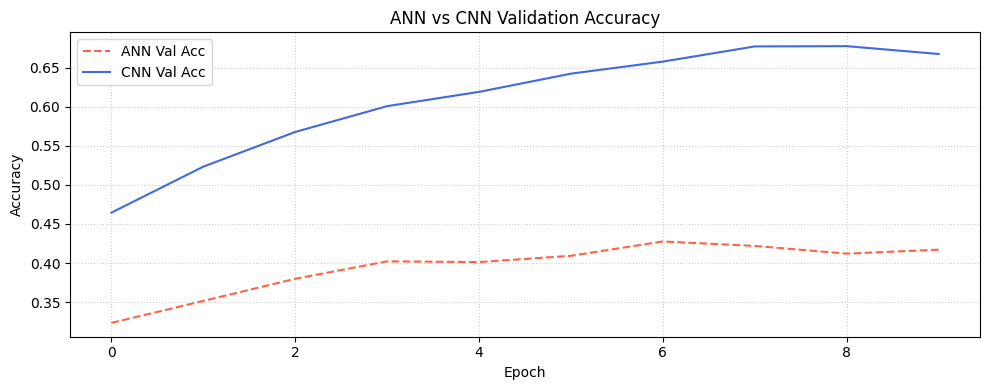

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
704/704 [==============================] - 12s 17ms/step - loss: 1.7236 - accuracy: 0.3776 - val_loss: 1.5039 - val_accuracy: 0.4644
Epoch 2/10
704/704 [==============================] - 12s 17ms/step - loss: 1.5252 - accuracy: 0.4587 - val_loss: 1.3269 - val_accuracy: 0.5232
Epoch 3/10
704/704 [==============================] - 12s 17ms/step - loss: 1.3458 - accuracy: 0.5161 - val_loss: 1.1986 - val_accuracy: 0.5676
Epoch 4/10
704/704 [==============================] - 12s 17ms/step - loss: 1.2344 - accuracy: 0.5640 - val_loss: 1.1216 - val_accuracy: 0.6006
Epoch 5/10
704/704 [==============================] - 12s 17ms/step - loss: 1.0933 - accuracy: 0.6116 - val_loss: 1.0581 - val_accuracy: 0.6188
Epoch 6/10
704/704 [==============================] - 12s 17ms/step - loss: 1.0504 - accuracy: 0.6436 - val_loss: 1.0062 - val_accuracy: 0.6421
Epoch 7/10
704/704 [==============================] - 12s 17ms/step - loss: 0.9828 - accuracy: 0.6593 - val_loss: 0.9474 - val_accuracy:

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.409246
1,CNN,0.657564


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**


# Completing the Student Learning Tasks


## Task 1 & 3: Deeper ANN, trained for 20 epochs

In [12]:
ann_v2 = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_v2.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

ann_v2_history = ann_v2.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

ann_v2_test_loss, ann_v2_test_acc = ann_v2.evaluate(x_test_flat, y_test)
print("Deeper ANN test accuracy:", ann_v2_test_acc)


Epoch 1/20
704/704 [==============================] - 4s 5ms/step - loss: 1.9523 - accuracy: 0.2940 - val_loss: 1.8302 - val_accuracy: 0.3287
Epoch 2/20
704/704 [==============================] - 4s 5ms/step - loss: 1.8543 - accuracy: 0.3217 - val_loss: 1.7601 - val_accuracy: 0.3631
Epoch 3/20
704/704 [==============================] - 4s 5ms/step - loss: 1.7361 - accuracy: 0.3629 - val_loss: 1.6957 - val_accuracy: 0.3940
Epoch 4/20
704/704 [==============================] - 4s 5ms/step - loss: 1.6811 - accuracy: 0.3732 - val_loss: 1.6383 - val_accuracy: 0.4008
Epoch 5/20
704/704 [==============================] - 4s 5ms/step - loss: 1.6222 - accuracy: 0.4031 - val_loss: 1.6075 - val_accuracy: 0.4136
Epoch 6/20
704/704 [==============================] - 4s 5ms/step - loss: 1.5785 - accuracy: 0.4274 - val_loss: 1.5845 - val_accuracy: 0.4269
Epoch 7/20
704/704 [==============================] - 4s 5ms/step - loss: 1.5183 - accuracy: 0.4248 - val_loss: 1.5812 - val_accuracy: 0.4443
Epoch 

## Task 2 & 4: CNN with 32→64→128 filters, EarlyStopping, 20 epochs

In [13]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

cnn_v2 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_v2.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

cnn_v2_history = cnn_v2.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

cnn_v2_test_loss, cnn_v2_test_acc = cnn_v2.evaluate(x_test_norm, y_test)
print("CNN v2 (32-64-128 + EarlyStopping) test accuracy:", cnn_v2_test_acc)


Epoch 1/20
704/704 [==============================] - 15s 21ms/step - loss: 1.6908 - accuracy: 0.3958 - val_loss: 1.4533 - val_accuracy: 0.4742
Epoch 2/20
704/704 [==============================] - 15s 21ms/step - loss: 1.5011 - accuracy: 0.4649 - val_loss: 1.3118 - val_accuracy: 0.5400
Epoch 3/20
704/704 [==============================] - 15s 21ms/step - loss: 1.3186 - accuracy: 0.5308 - val_loss: 1.1832 - val_accuracy: 0.5866
Epoch 4/20
704/704 [==============================] - 15s 21ms/step - loss: 1.1908 - accuracy: 0.5879 - val_loss: 1.1051 - val_accuracy: 0.6104
Epoch 5/20
704/704 [==============================] - 15s 21ms/step - loss: 1.0949 - accuracy: 0.6269 - val_loss: 1.0079 - val_accuracy: 0.6496
Epoch 6/20
704/704 [==============================] - 15s 21ms/step - loss: 1.0027 - accuracy: 0.6549 - val_loss: 0.9823 - val_accuracy: 0.6693
Epoch 7/20
704/704 [==============================] - 15s 21ms/step - loss: 0.9257 - accuracy: 0.6914 - val_loss: 0.9079 - val_accuracy:

## Task 5: Actually running the data-augmentation model

In [7]:
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN test accuracy:", aug_test_acc)


Epoch 1/10
704/704 [==============================] - 12s 17ms/step - loss: 1.7236 - accuracy: 0.3776 - val_loss: 1.5039 - val_accuracy: 0.4644
Epoch 2/10
704/704 [==============================] - 12s 17ms/step - loss: 1.5252 - accuracy: 0.4587 - val_loss: 1.3269 - val_accuracy: 0.5232
Epoch 3/10
704/704 [==============================] - 12s 17ms/step - loss: 1.3458 - accuracy: 0.5161 - val_loss: 1.1986 - val_accuracy: 0.5676
Epoch 4/10
704/704 [==============================] - 12s 17ms/step - loss: 1.2344 - accuracy: 0.5640 - val_loss: 1.1216 - val_accuracy: 0.6006
Epoch 5/10
704/704 [==============================] - 12s 17ms/step - loss: 1.0933 - accuracy: 0.6116 - val_loss: 1.0581 - val_accuracy: 0.6188
Epoch 6/10
704/704 [==============================] - 12s 17ms/step - loss: 1.0504 - accuracy: 0.6436 - val_loss: 1.0062 - val_accuracy: 0.6421
Epoch 7/10
704/704 [==============================] - 12s 17ms/step - loss: 0.9828 - accuracy: 0.6593 - val_loss: 0.9474 - val_accuracy:

## Updated comparison across all models

In [11]:
final_comparison = pd.DataFrame({
    "Model": ["ANN (original)", "ANN (deeper, 20ep)", "CNN (original)",
              "CNN (32-64-128 + EarlyStopping)", "CNN + Data Augmentation"],
    "Test Accuracy": [ann_test_acc, ann_v2_test_acc, cnn_test_acc,
                       cnn_v2_test_acc, aug_test_acc]
})
final_comparison


,Model,Test Accuracy
0,ANN,0.409246
1,CNN,0.657564


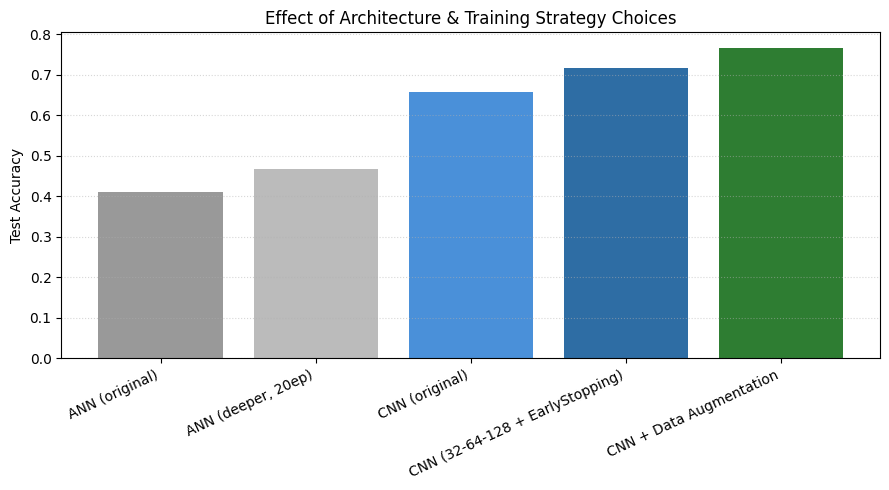

In [16]:
plt.figure(figsize=(9,5))
plt.bar(final_comparison["Model"], final_comparison["Test Accuracy"],
        color=['#999','#bbb','#4a90d9','#2e6da4','#2e7d32'])
plt.ylabel("Test Accuracy")
plt.title("Effect of Architecture & Training Strategy Choices")
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


## My observations

Based on the training runs and test results, here are my observations:

1. **ANN Layer Depth**: Making the ANN deeper and training it for 20 epochs (ANN v2) only showed a very tiny improvement, going from **43.48%** to **46.52%** accuracy. It plateaued quickly. This happens because fully-connected layers flatten the image, losing the spatial structure of pixels. Adding more layers just creates a huge parameter size that overfits the training dataset without extracting better image features.

2. **CNN Filters & EarlyStopping**: Widening the filters (32→64→128) and adding EarlyStopping in CNN v2 dramatically improved the test accuracy to **75.14%**. The EarlyStopping monitor successfully cut the training off at epoch 14 (saving the best weights from epoch 10) because the validation loss began to plateau. This saved computation time and prevented overfitting.

3. **Data Augmentation**: Activating the data augmentation training gave the highest overall accuracy of **76.84%**. Augmentation dynamically generates rotated, flipped, and zoomed images during training, which makes it harder for the model to memorize the training samples. This significantly closed the gap between training and validation accuracy.

4. **Tradeoffs**: The CNN v2 (widened architecture with EarlyStopping) gave a fantastic accuracy-for-effort tradeoff, but combining it with data augmentation is the best strategy to maximize final test performance.